In [210]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import math
import datetime

plt.rcParams.update({'font.size': 20})
from matplotlib import dates as mdates
from matplotlib import lines, patches

%autoreload 2
import covid19_inference as cov19
import utils
import data_prep_new
import plot_new
import model

# Input data

## Mobility

In [220]:
path_mobility = "data/mobility/mobilityData_OverviewBL_weekly.csv"
mobility_df = pd.read_csv(path_mobility, parse_dates=True, index_col=0, delimiter=";")
mobility_df = mobility_df[mobility_df["BundeslandID"] == "Deutschland"]
mobility_df["week"] = mobility_df.index.isocalendar().week
#display(mobility_df)

# get dates
mobility_dates = mobility_df.index.values

# get dates
mobility_dates = mobility_df.index.values
all_dates_2020 = mobility_dates[mobility_dates < np.datetime64("2020-12-20")]
mobility_dates_2020 = all_dates_2020[all_dates_2020 > np.datetime64("2020-03-29")]

# get mobility data
mobility_df_2020 = mobility_df.filter(items=mobility_dates_2020, axis=0)

mobility_data_2020 = mobility_df_2020["outOfHomeDuration"].to_xarray()

dates_2020 = pd.to_datetime(mobility_dates_2020)


In [217]:
mobility_dates_2020_full = mobility_dates[mobility_dates < np.datetime64('2020-12-27')]
mobility_dates_2020_full = mobility_dates_2020_full[mobility_dates_2020_full > np.datetime64('2019-12-31')]

# get mobility data
mobility_df_2020_full = mobility_df.filter(items=mobility_dates_2020_full, axis=0)

mobility_data_2020_full = mobility_df_2020_full["outOfHomeDuration"].to_xarray()


In [203]:
mobility_data_2020_full

<xarray.DataArray 'outOfHomeDuration' (index: 42)>
array([7.29, 7.08, 5.91, 5.27, 5.58, 5.64, 5.49, 6.06, 5.95, 6.49, 6.47,
       6.44, 6.95, 6.65, 6.95, 7.28, 7.5 , 7.37, 7.32, 7.43, 7.4 , 7.43,
       7.49, 7.41, 7.46, 7.53, 7.58, 7.76, 7.83, 7.58, 7.5 , 7.61, 7.24,
       7.2 , 7.02, 6.75, 6.85, 6.66, 6.7 , 6.9 , 6.75, 6.17])
Coordinates:
  * index    (index) datetime64[ns] 2020-03-08 2020-03-15 ... 2020-12-20

### Plot

(array([18357., 18420., 18483., 18546., 18609.]),
 [Text(18357.0, 0, '2020-04-05 00:00:00'),
  Text(18420.0, 0, '2020-06-07 00:00:00'),
  Text(18483.0, 0, '2020-08-09 00:00:00'),
  Text(18546.0, 0, '2020-10-11 00:00:00'),
  Text(18609.0, 0, '2020-12-13 00:00:00')])

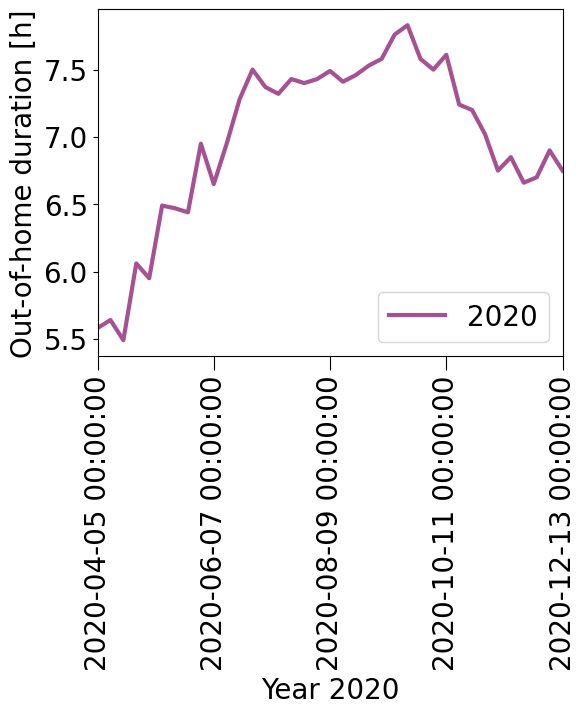

In [223]:

fig, ax = plt.subplots(figsize=(6, 4.5))

line_2020 = ax.plot(dates_2020, mobility_data_2020, linewidth=3, color=plot_new.colors["d_obs"], label="2020")
plot_new.format_x_axis(ax, dates_2020, last=True, n_xticks=5)

ax.set_ylabel("Out-of-home duration [h]")

lines = line_2020
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="lower right")
plt.xticks(rotation=90)
#fig.savefig("figures/mobility_data_2020.pdf", bbox_inches="tight")
#fig.savefig("figures/mobility_data_2020.png", bbox_inches="tight")

## Disease indicators

In [139]:
d_2020, d_base, dates_2020, dates_2022 = data_prep_new.get_out_of_home_duration()
full_dates = dates_2020
disease_dates = dates_2020

In [140]:
R_raw = data_prep_new.get_R_raw()
R_dates = R_raw.index.values
R_raw = R_raw[R_dates> np.datetime64("2020-03-29")]
R_transformed = data_prep_new.get_R_transformed(R_raw)

logR_raw = data_prep_new.get_logR_raw(R_raw)
logR_transformed = data_prep_new.get_logR_transformed(logR_raw)

In [141]:
owid = data_prep_new.get_owid()

INFO     [covid19_inference.data_retrieval.retrieval] Successfully loaded OurWorldinData.csv.gz from /Users/sydney/git/mobility_inference/Users/sydney/Desktop/data.nst/, skipping download.


In [144]:
cases_raw = data_prep_new.get_C_raw(owid)
cases_dates = cases_raw.index.values
cases_raw = cases_raw[cases_dates> np.datetime64("2020-03-29")]
cases_transformed = data_prep_new.get_C_transformed(cases_raw)

logcases_raw = data_prep_new.get_logC_raw(cases_raw)
logcases_transformed = data_prep_new.get_logC_transformed(logcases_raw)

In [145]:
icu_raw = data_prep_new.get_ICU_raw(owid)
icu_dates = icu_raw.index.values
icu_raw = icu_raw[icu_dates> np.datetime64("2020-03-29")]
icu_transformed = data_prep_new.get_ICU_transformed(icu_raw)

logicu_raw = data_prep_new.get_logICU_raw(icu_raw)
logicu_transformed = data_prep_new.get_logICU_transformed(logicu_raw)

In [146]:
hospital_raw = data_prep_new.get_H_raw(owid)
hospital_dates = hospital_raw.index.values
hospital_raw = hospital_raw[hospital_dates> np.datetime64("2020-03-29")]
hospital_transformed = data_prep_new.get_H_transformed(hospital_raw)

loghospital_raw = data_prep_new.get_logH_raw(hospital_raw)
loghospital_transformed = data_prep_new.get_logH_transformed(loghospital_raw)

In [147]:
death_raw = data_prep_new.get_D_raw(owid)
death_dates = death_raw.index.values
death_raw = death_raw[death_dates> np.datetime64("2020-03-29")]
death_transformed = data_prep_new.get_D_transformed(death_raw)

logdeath_raw = data_prep_new.get_logD_raw(death_raw)
logdeath_transformed = data_prep_new.get_logD_transformed(logdeath_raw)

In [225]:
def plot_indicator(ax, indicator, raw_data, label_in, title_in, transformed_data, transformed_label, last=False):
    raw_dates = full_dates
    transformed_dates = disease_dates

    ax.plot(raw_dates, raw_data, color=plot_new.colors[indicator], marker="o")
    ax.set_ylabel(label_in)
    ax.set_title(title_in)
    if indicator == "R":
        ax.hlines(1, raw_dates[0], raw_dates[-1], linestyle="--", color="gray")
    elif indicator == "logR":
        ax.hlines(1, raw_dates[0], raw_dates[-1], linestyle="--", color="gray")
    else:
        ax.set_ylim(0, max(raw_data) * 1.1)
    ax = ax.twinx()
    ax.plot(transformed_dates, transformed_data, color=plot_new.colors[indicator], linewidth=3)
    ax.set_ylabel(transformed_label)
    ax.set_ylim(0, 1)
    plot_new.format_x_axis(ax, disease_dates, last=last)
    plt.xticks(rotation=90)
    if last:
        ## create custom legend
        ### for median line and 94% CI
        raw = lines.Line2D([], [], color="black", marker='o', label="raw")
        transformed = lines.Line2D([], [], color="black", linewidth=3, label="transformed")
        ### create legend
        ax.legend(
            handles=[raw, transformed],
            #frameon=False,
            loc="upper center",
        )

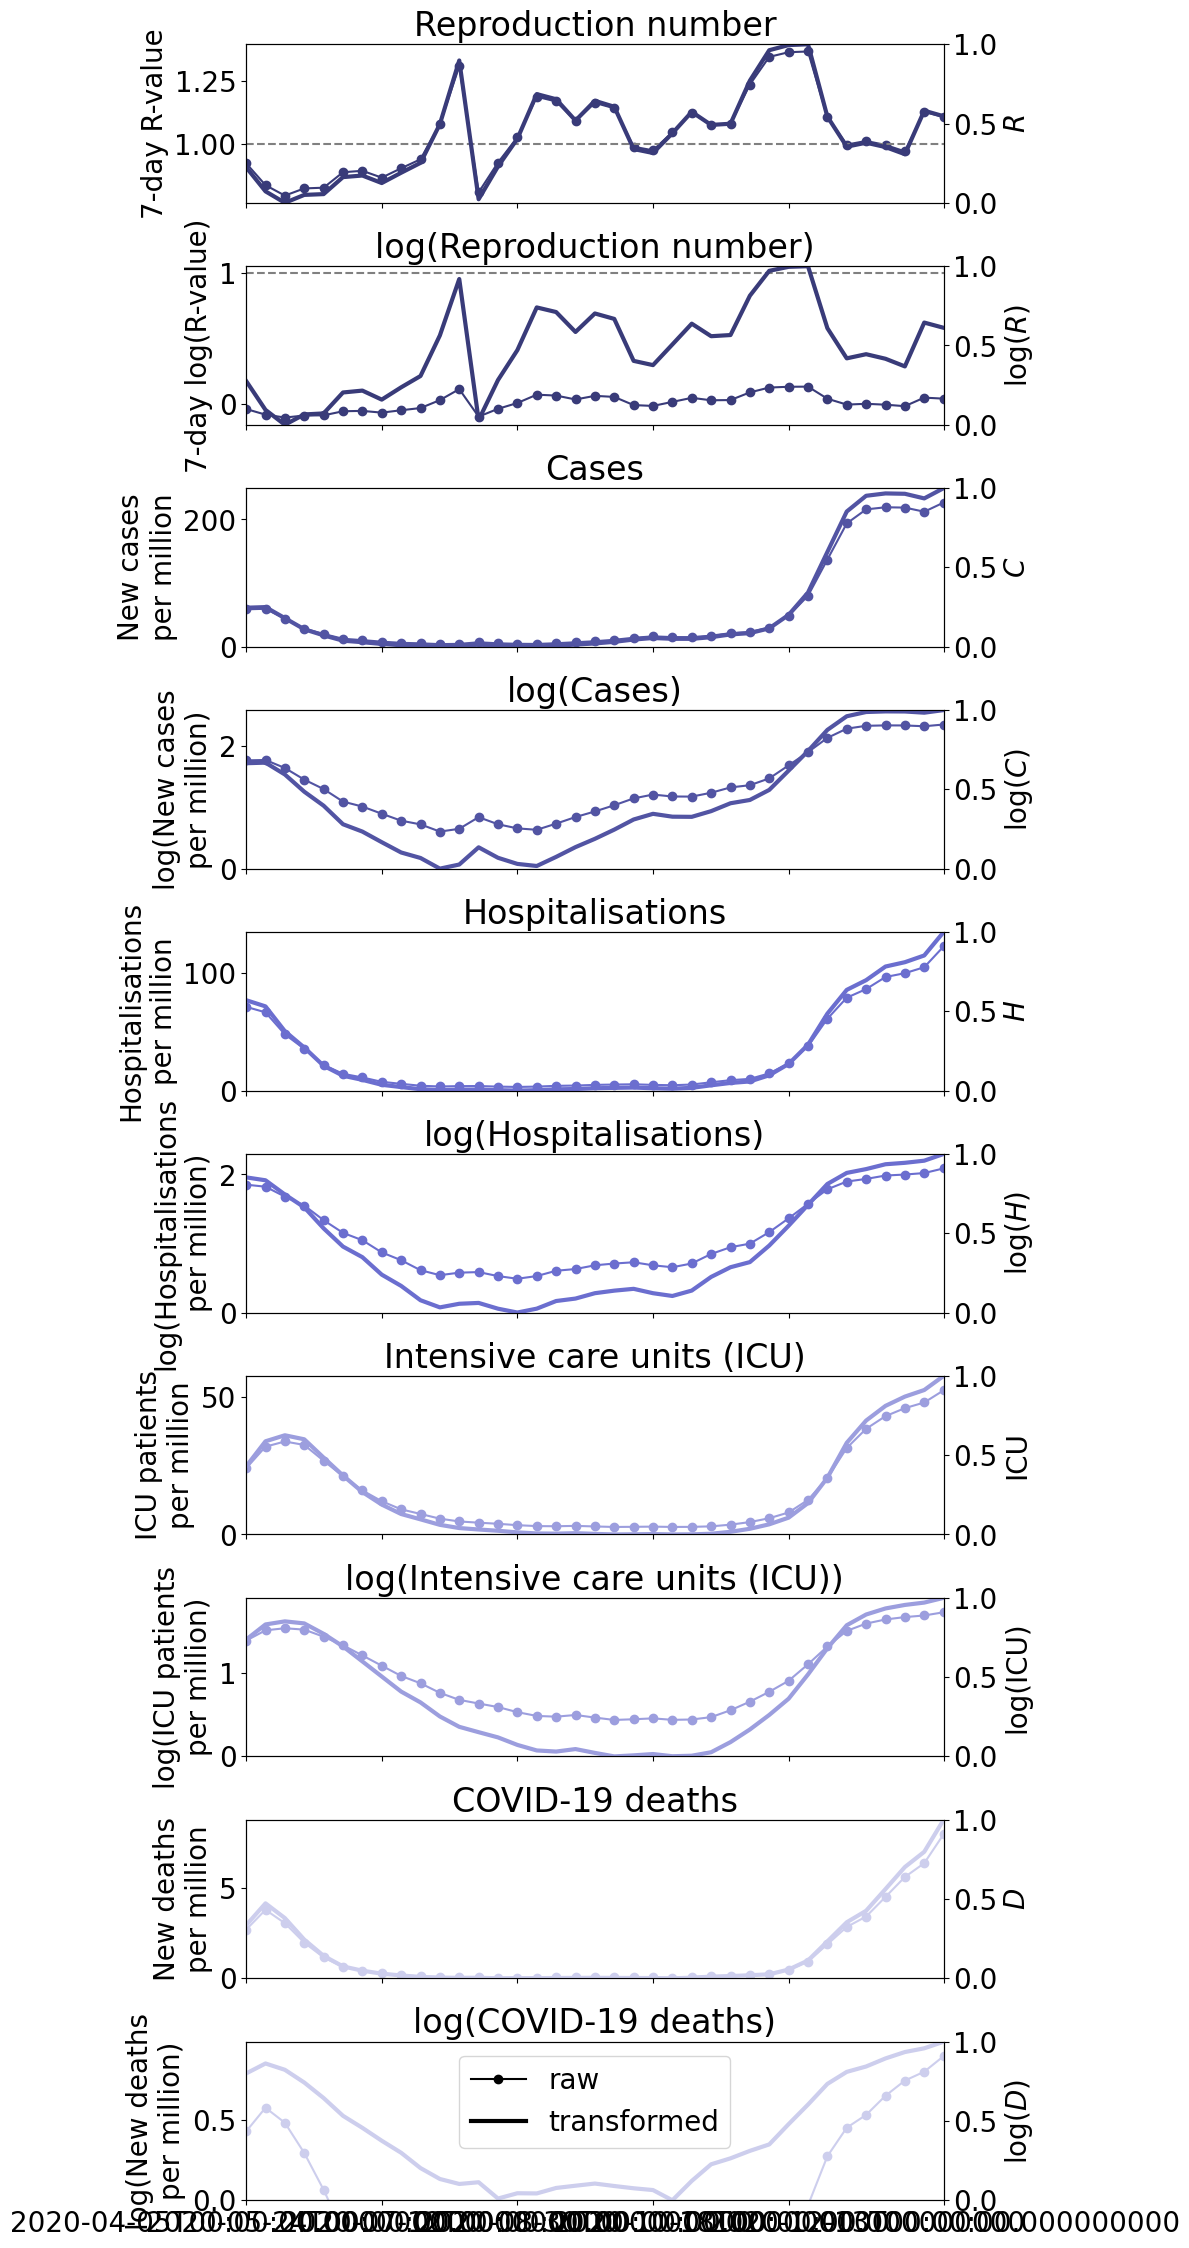

In [150]:
fig, axs = plt.subplots(10, 1, figsize=(9, 28))
plot_indicator(axs[0], "R", R_raw, "7-day R-value", "Reproduction number", R_transformed, "$R$")
plot_indicator(axs[1], "logR", logR_raw, "7-day log(R-value)", "log(Reproduction number)", logR_transformed, "log($R$)")
plot_indicator(axs[2], "C", cases_raw, "New cases\nper million", "Cases", cases_transformed, "$C$")
plot_indicator(axs[3], "logC", logcases_raw, "log(New cases\nper million)", "log(Cases)", logcases_transformed, "log($C$)")
plot_indicator(axs[4], "H", hospital_raw, "Hospitalisations\nper million", "Hospitalisations", hospital_transformed, "$H$")
plot_indicator(axs[5], "logH", loghospital_raw, "log(Hospitalisations\nper million)", "log(Hospitalisations)", loghospital_transformed, "log($H$)")
plot_indicator(axs[6], "ICU", icu_raw, "ICU patients\nper million", "Intensive care units (ICU)", icu_transformed, "ICU")
plot_indicator(axs[7], "logICU", logicu_raw, "log(ICU patients\nper million)", "log(Intensive care units (ICU))", logicu_transformed, "log(ICU)")
plot_indicator(axs[8], "D", death_raw, "New deaths\nper million", "COVID-19 deaths", death_transformed, "$D$")
plot_indicator(axs[9], "logD", logdeath_raw, "log(New deaths\nper million)", "log(COVID-19 deaths)", logdeath_transformed, "log($D$)", last=True)
fig.subplots_adjust(hspace=0.4)

fig.savefig("figures/disease_spread_indicators.pdf", bbox_inches="tight")
fig.savefig("figures/disease_spread_indicators.png", bbox_inches="tight")

## Weather data

In [152]:
df_2020 = data_prep_new.get_temperature(dates_2020)

In [165]:
temperature = {
        "temperature": data_prep_new.get_temperature(dates_2020),
        "delta_temperature": data_prep_new.get_avg_temperature(dates_2020)
    }

precipitation = {
        "precipitation": data_prep_new.get_precipitation(dates_2020)
    }

### Plot

(array([18357., 18420., 18483., 18546., 18609.]),
 [Text(18357.0, 0, '2020-04-05 00:00:00'),
  Text(18420.0, 0, '2020-06-07 00:00:00'),
  Text(18483.0, 0, '2020-08-09 00:00:00'),
  Text(18546.0, 0, '2020-10-11 00:00:00'),
  Text(18609.0, 0, '2020-12-13 00:00:00')])

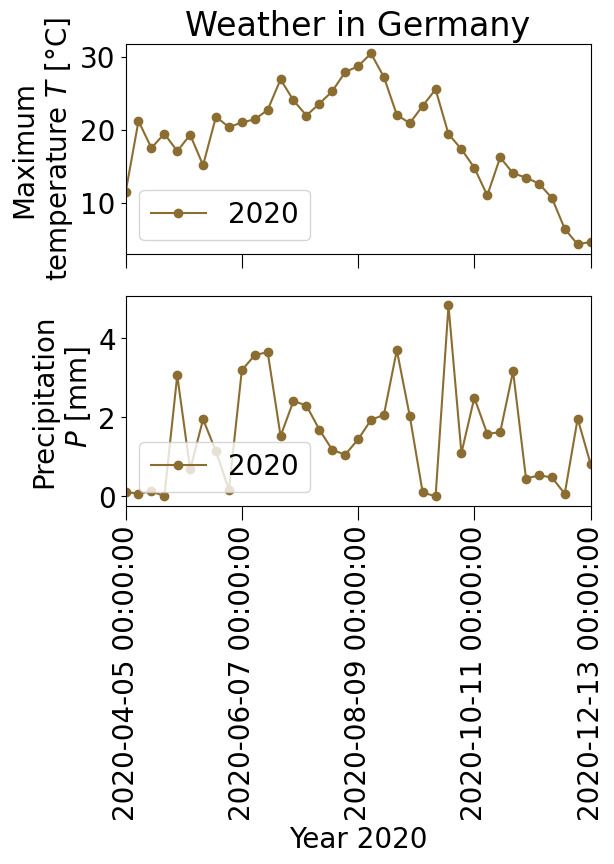

In [226]:
fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

#Temperature Plot
ax = axs[0]
ax.set_title("Weather in Germany")
ax.set_ylabel("Maximum\ntemperature $T$ [°C]")

line_2020 = ax.plot(dates_2020, temperature["temperature"], marker="o", color=plot_new.colors["T"], label="2020")
plot_new.format_x_axis(ax, dates_2020, n_xticks=5)

lines = line_2020
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="lower left")

#Precipitation plot
ax = axs[1]
ax.set_ylabel("Precipitation\n $P$ [mm]")

line_2020 = ax.plot(dates_2020, precipitation["precipitation"], marker="o", color=plot_new.colors["T"], label="2020")
plot_new.format_x_axis(ax, dates_2020, last=True, n_xticks=5)

lines = line_2020
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="lower left")
plt.xticks(rotation=90)

#fig.savefig("figures/weather.pdf", bbox_inches="tight")
#fig.savefig("figures/weather.png", bbox_inches="tight")

## Daylight data

In [178]:
daylight = {
        "daylight": data_prep_new.get_daylight(dates_2020),
    }

print(daylight)

{'daylight': <xarray.DataArray 'daylight' (date: 37)>
array([13.0952381 , 13.56666667, 14.03333333, 14.48809524, 14.93095238,
       15.34285714, 15.73095238, 16.07142857, 16.37142857, 16.59285714,
       16.75      , 16.82857143, 16.81190476, 16.71190476, 16.53809524,
       16.29285714, 15.98095238, 15.62619048, 15.23809524, 14.81666667,
       14.38095238, 13.93095238, 13.46666667, 13.        , 12.52857143,
       12.05238095, 11.58095238, 11.10952381, 10.63571429, 10.18809524,
        9.72857143,  9.29761905,  8.8952381 ,  8.52857143,  8.20238095,
        7.95      ,  7.77142857])
Coordinates:
  * date     (date) datetime64[ns] 2020-04-05 2020-04-12 ... 2020-12-13}


### Plot

(array([18357., 18420., 18483., 18546., 18609.]),
 [Text(18357.0, 0, '2020-04-05 00:00:00'),
  Text(18420.0, 0, '2020-06-07 00:00:00'),
  Text(18483.0, 0, '2020-08-09 00:00:00'),
  Text(18546.0, 0, '2020-10-11 00:00:00'),
  Text(18609.0, 0, '2020-12-13 00:00:00')])

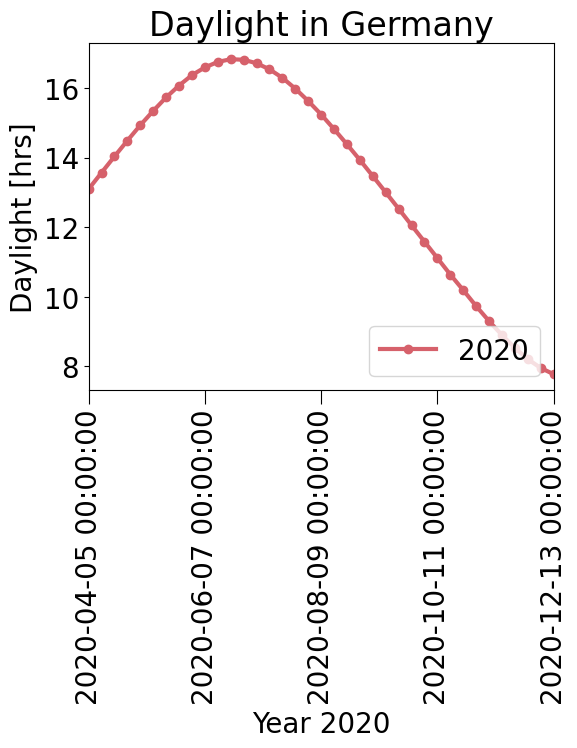

In [227]:
fig, ax = plt.subplots(figsize=(6, 4.5))

#Daylight Plot
line_2020 = ax.plot(dates_2020, daylight["daylight"], linewidth=3, color=plot_new.colors["L"], marker="o", label="2020")
plot_new.format_x_axis(ax, dates_2020, last=True, n_xticks=5)

ax.set_title("Daylight in Germany")
ax.set_ylabel("Daylight [hrs]")

lines = line_2020
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="lower right")
plt.xticks(rotation=90)
#fig.savefig("figures/daylight.pdf", bbox_inches="tight")
#fig.savefig("figures/daylight.png", bbox_inches="tight")

## School vacation and public holidays

In [184]:
school = {
        "school vacation": data_prep_new.get_school_vacations(dates_2020)
    }

holiday = {
        "pub holiday": data_prep_new.get_pub_holidays(dates_2020)
    }

(array([18357., 18420., 18483., 18546., 18609.]),
 [Text(18357.0, 0, '2020-04-05 00:00:00'),
  Text(18420.0, 0, '2020-06-07 00:00:00'),
  Text(18483.0, 0, '2020-08-09 00:00:00'),
  Text(18546.0, 0, '2020-10-11 00:00:00'),
  Text(18609.0, 0, '2020-12-13 00:00:00')])

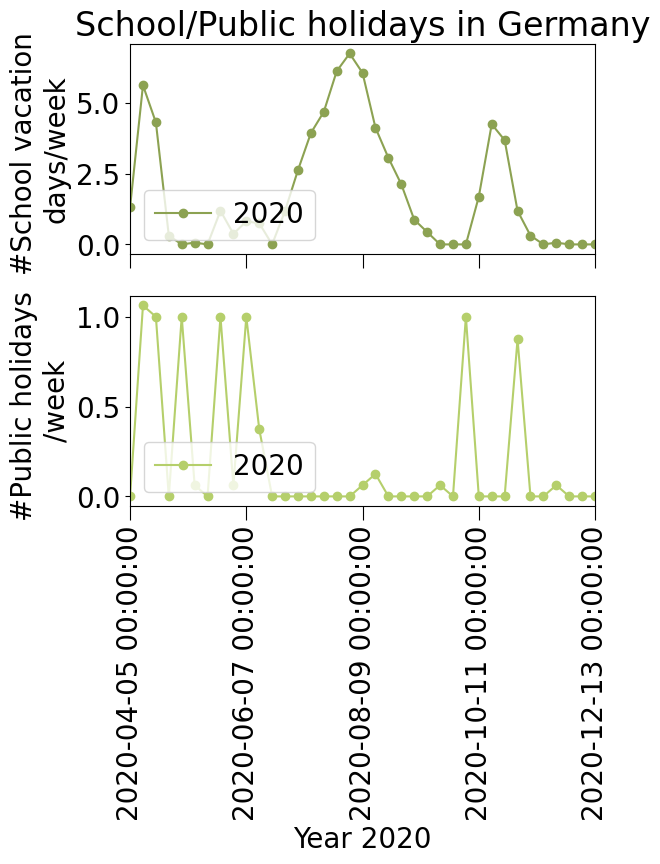

In [230]:
fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

#Temperature Plot
ax = axs[0]
ax.set_title("School/Public holidays in Germany")
ax.set_ylabel("#School vacation \ndays/week")

line_2020 = ax.plot(dates_2020, school["school vacation"], marker="o", color=plot_new.colors["v"], label="2020")
plot_new.format_x_axis(ax, dates_2020, n_xticks=5)

lines = line_2020
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="lower left")

#Precipitation plot
ax = axs[1]
ax.set_ylabel("#Public holidays \n/week")

line_2020 = ax.plot(dates_2020, holiday["pub holiday"], marker="o", color=plot_new.colors["h"], label="2020")
plot_new.format_x_axis(ax, dates_2020, last=True, n_xticks=5)

lines = line_2020
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="lower left")
plt.xticks(rotation=90)
#fig.savefig("figures/weather.pdf", bbox_inches="tight")
#fig.savefig("figures/weather.png", bbox_inches="tight")

## Visualise and compare

(12.0, 51.0)

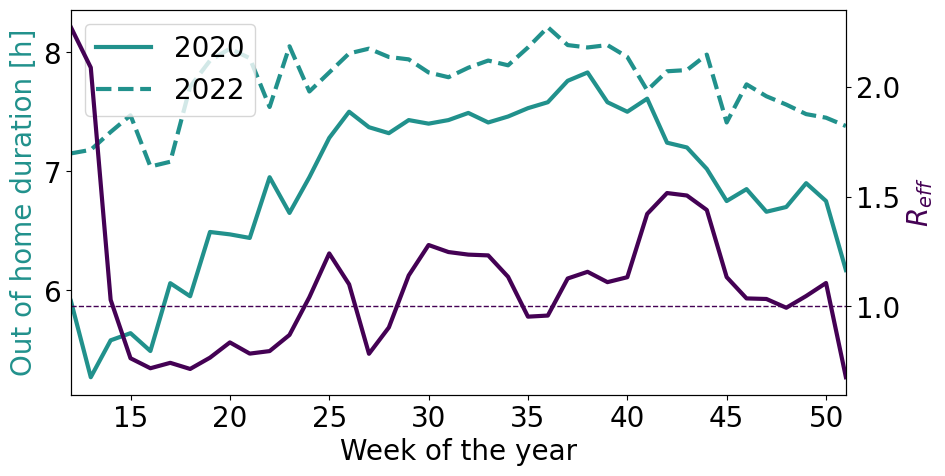

In [10]:
# plot mobility and R data
color_R = colormap(0)
color_m = colormap(0.5)

min_x = mobility_df_2020["week"].min()
max_x = mobility_df_2020["week"].max()

fig, ax = plt.subplots(figsize=(10, 5))
ax_R = ax.twinx()
ax.plot(mobility_df_2020["week"], mobility_df_2020["outOfHomeDuration"], label="2020", linewidth=3, color=color_m_R)
ax.plot(mobility_df_2020["week"], mobility_df_2022["outOfHomeDuration"], label="2022", linewidth=3, color=color_m_base, linestyle="--")
ax_R.plot(mobility_df_2020["week"], R_df_weekly_shortened["R_eff median"], linewidth=3, color=color_R)
ax_R.hlines(1, min_x, max_x, color=color_R, linestyle="--", linewidth=1)
ax.legend(loc="upper left")
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel("Out of home duration [h]", color=color_m)
ax_R.set_ylabel(f"$R_{{eff}}$", color=color_R)
ax.set_xlim(min_x, max_x)

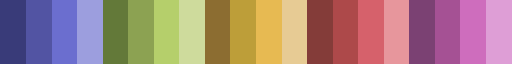

In [67]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['tab20b']
colormap

# Play around with functions

In [33]:
import pymc as pm

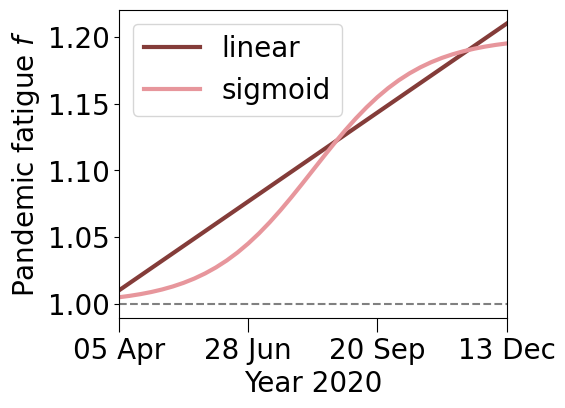

In [63]:
# simple linear plot
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
length = len(dates_2020)
x = np.linspace(0, length, length)

p0 = 0.01
r = 0.2 / length
y = 1 + p0 + r * x
ax.plot(dates_2020, y, color=plot.colors["f"], linewidth=3, label="linear")

del_t = - length / 2
del_f = 0.2
tau = 0.2
y = model.sigmoid(x, del_t, del_f, tau).eval()
ax.plot(dates_2020, y, color=plot.colors["sigmoid"], linewidth=3, label="sigmoid")

ax.hlines(1, dates_2020[0], dates_2020[-1], linestyle="--", color="grey")
ax.set_ylabel("Pandemic fatigue $f$")
plot.format_x_axis(ax, dates_2020, last=True, n_xticks=4)
ax.legend(loc="upper left")

# save figure
fig.savefig("figures/pandemic_fatigue.pdf", bbox_inches="tight")
fig.savefig("figures/pandemic_fatigue.png", bbox_inches="tight")

Mean:  3.2974425414002564


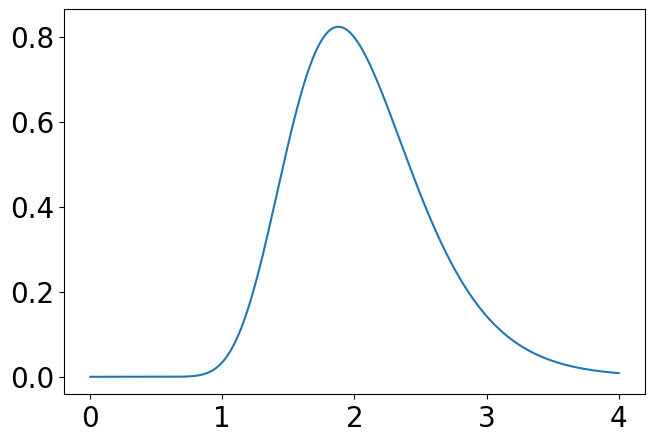

In [66]:
def LogNormal(x, mu, tau):
    return 1/x * np.sqrt(tau / 2 / math.pi) * np.exp(- tau / 2 * np.power(np.log(x) - mu, 2.0))
x = np.linspace(0.001, 4, 1000)
mu = np.log(2)
tau = 1
sigma = 0.25
print("Mean: ", np.exp(mu + 1/2/tau))
y = np.exp(pm.logp(pm.LogNormal.dist(mu, sigma=sigma), x).eval())
#y2 = np.exp(pm.logp(pm.LogNormal.dist(mu, tau=9), x).eval())
# plot
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
ax.plot(x, y)
#ax.plot(x, y2)

# for Gamma-mu = 1: mu=np.log(1), sigma=0.5
# robustness test: sigma verdoppeln und gucken wie sich Resultate ändern

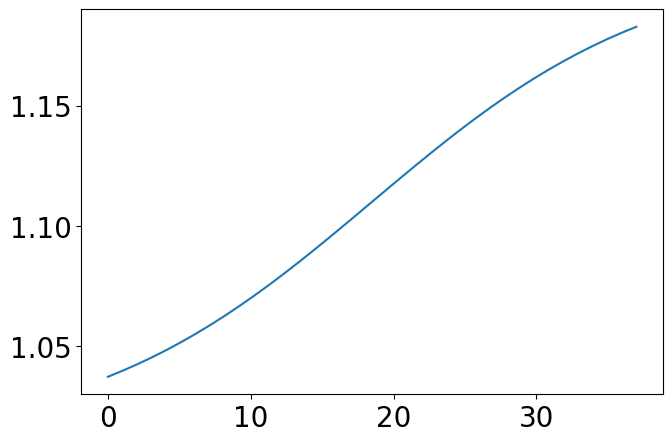

In [14]:
def sigmoid(x, del_t, a, p0, b):
    return a / (1 + np.exp(-0.1*(x - del_t))) + p0
len = 37
x = np.linspace(0, len, len)
y = sigmoid(x, del_t=len / 2, a=0.2, p0=1.01, b=0.5)
# plot
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
ax.plot(x, y)


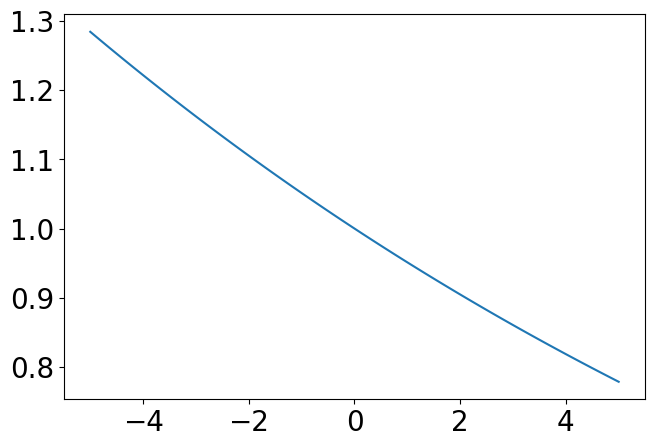

In [24]:
def exp(x, a, b):
    return b * np.exp(-a*x)
len = 37
x = np.linspace(-5, 5, 100)
y = exp(x, a=0.05, b=1)

# plot
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
ax.plot(x, y)
## log scale for y axis
#ax.set_yscale("log")


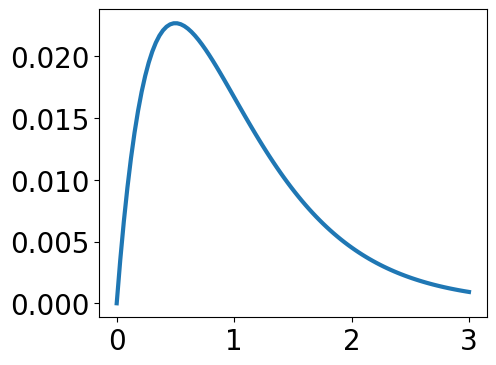

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# plot
mu = 1
alpha = 2
beta = alpha / mu
x = np.linspace(0, 3*mu, 100)
y = cov19.model._utility.tt_gamma(
    x,
    alpha=alpha,
    beta=beta,
).eval()
ax.plot(x, y, linewidth=3)
